# STOR 235 — Lab 3

In this lab, you will apply support vector classifiers to real data. You will also learn a bit about handling tabular data using the `pandas` package and data visualization using the `seaborn` package.

## Instructions

There are two parts to this lab:



1.   The wine dataset;
2.   The MNIST handwriting recognition dataset.


Each part will be composed of a number of tasks for you to complete. The tasks are labeled in bold as **Problem 1**, **Problem 2**, and so on. Please make sure that you do not forget to complete any of the problems. Each problem will be worth 5 points.

There is a single code block in under this introductory material that imports various things you will use later. Please run it.


In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier

#Part 1: Wine Dataset

The `wine` dataset comes with the scikit-learn package, which gives a special function to load it. The following code block loads the dataset and converts it to a `pandas` dataframe, which is essentially a spreadsheet-type data structure. Each row is a datapoint, and each column is an attribute.

By doing this, we can use several useful features of the `pandas` package to explore the data.

In [20]:
# Load the wine dataset
wine = load_wine()

# Convert the dataset to a pandas DataFrame for easier manipulation
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

#initially, the dataframe just has the 13 wine attributes
#the following line adds a new column with the class ("target") label
wine_df['target'] = wine.target

The following command prints basic information about the data. It tells us how many columns there are and what kind of data they contain.

In [21]:
print(wine_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

The following command prints the first six rows. If you want to see more, you can of course change the number 6 to something else.

In [22]:
print(wine_df.head(6))

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   
5    14.20        1.76  2.45               15.2      112.0           3.27   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             

We next look at basic summary statistics, like minimum values, maximum values, and quantiles.

In [23]:
print(wine_df.describe())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

The following code counts the number of wines in each of the three classes.

In [24]:
print(wine_df['target'].value_counts())

target
1    71
0    59
2    48
Name: count, dtype: int64


The following code plots a histogram of the `alcohol` values using the function `hist_plot` from `seaborn`. This package provides many fun possibilities for data visualization. See [the seaborn gallery](https://seaborn.pydata.org/examples/index.html) for more.

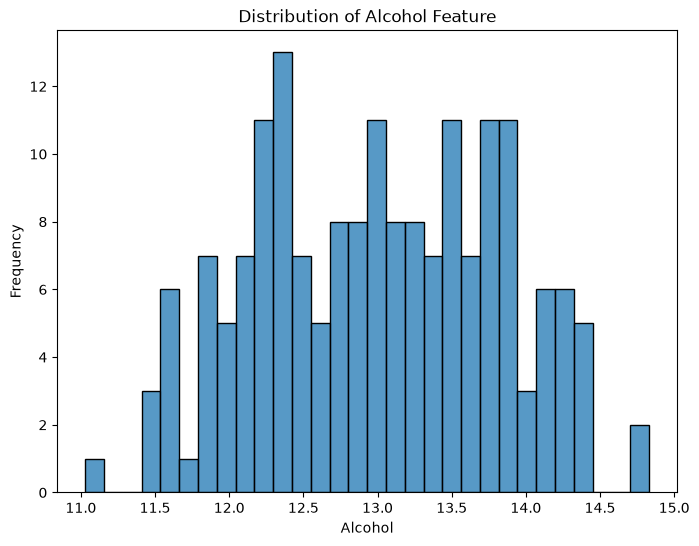

In [25]:
plt.figure(figsize=(8, 6))
sns.histplot(wine_df['alcohol'],  bins=30)
plt.title('Distribution of Alcohol Feature')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.show()

Next, we produce a scatterplot using `seaborn` based on two of the features.

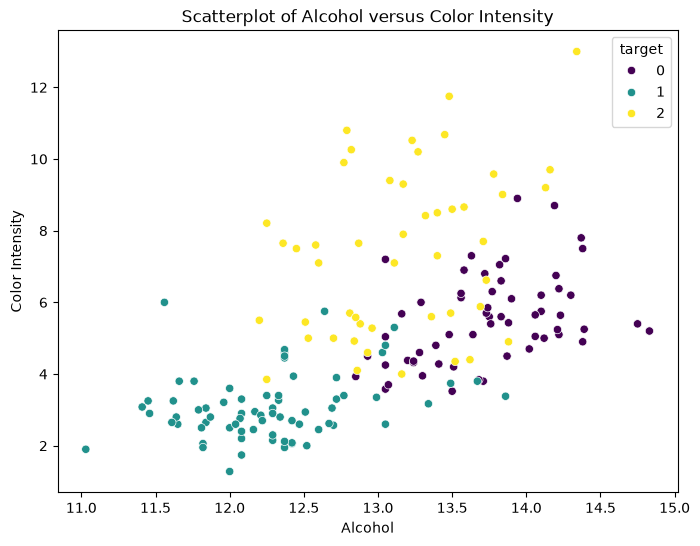

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='alcohol', y='color_intensity', hue='target', data=wine_df, palette='viridis')
plt.title('Scatterplot of Alcohol versus Color Intensity')
plt.xlabel('Alcohol')
plt.ylabel('Color Intensity')
plt.show()

In the next code block, I've written some code that trains a SVC on just two of the classes and two of the features, to make visualization easy. Then I've added some custom plotting code that shows the decision boundary and the margin. Note that the dots for the two classes are the same as those in the previous figure (perhaps with a little rescaling).

The plotting code is messy and you can ignore it. But you should pay careful attention to how the SVC is trained. First, `svm_binary` is created with certain options, then it is fit on the data. Later, `predict` is called to get the predictions from it. (Ignore the `ravel` stuff; I just did this to get the plotting to work. A clearer example of prediction is below.)

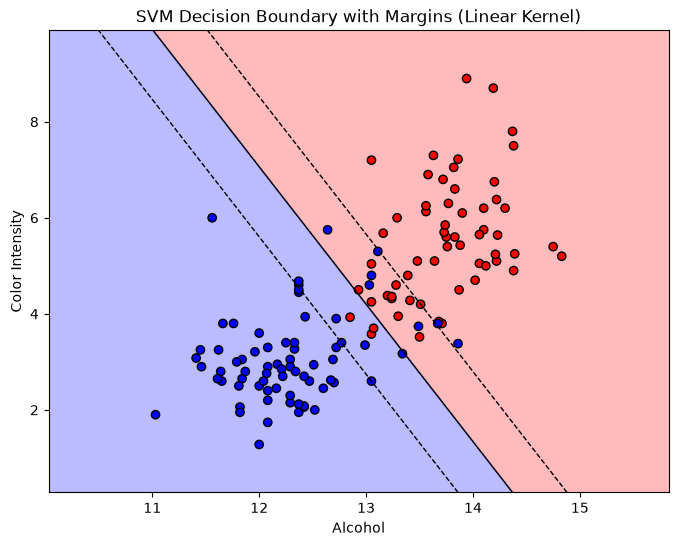

In [27]:
# Filter the dataset to include only classes 0 and 1
wine_filtered = wine_df[wine_df['target'] != 2]

# Select features for training (using 'alcohol' and 'color_intensity' as features)
X = wine_filtered[['alcohol', 'color_intensity']].values
y = wine_filtered['target'].values

# Train the SVM with a linear kernel
svm_binary = SVC(C=1, kernel='linear')
svm_binary.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class labels for each point in the mesh (for solid color regions)
Z = svm_binary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Compute decision function values (for margin and decision boundary)
decision_values = svm_binary.decision_function(np.c_[xx.ravel(), yy.ravel()])
decision_values = decision_values.reshape(xx.shape)

# Plot the decision boundary with solid regions and margin lines
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))  # Solid colors
plt.contour(xx, yy, decision_values, levels=[-1, 0, 1],
            linestyles=['--', '-', '--'], colors='k', linewidths=1)  # Margins and decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']), edgecolors='k')  # Data points
plt.title('SVM Decision Boundary with Margins (Linear Kernel)')
plt.xlabel('Alcohol')
plt.ylabel('Color Intensity')
plt.show()

Now we use all features to train the SVC. (Since this is 13-dimensional, unfortunately I could not produce a simple visualization.)

We implement a test-train split using a built-in function from `scikit-learn`, then call the `fit` and `predict` functions as before.

The last three lines show how you can print the data points from the training set and their associated predicted labels.

The first line of code looks a little complicated, but it just removes the `target` value, leading the 13 numerical attributes.

In [28]:
# Use all features and all classes
x_full = wine_df.drop(columns=['target']).values
y_full = wine_df['target'].values

# Split into 70% training and 30% testing
x_train, x_test, y_train, y_test = train_test_split(x_full, y_full, test_size=0.3)

# Train SVM with a linear kernel
svm_full = SVC(C = 1, kernel='linear')
svm_full.fit(x_train, y_train)

y_pred = svm_full.predict(x_test)

print(x_test[0]) #attributes for first member of test set
print(y_test[0]) #label for first member of test set
print(y_pred[0]) #predicted label for first member of test set

[ 12.64   1.36   2.02  16.8  100.     2.02   1.41   0.53   0.62   5.75
   0.98   1.59 450.  ]
1
2


We can use some built-in functions to compute the accuracy and print a confusion matrix. This dataset is not so challenging, so we reach almost perfect accuracy. (Depending on the randomness in the train-test split, you might even get 100% on the test set.) This indicates that our classifer is doing a great job.

Test Accuracy: 0.9629629629629629


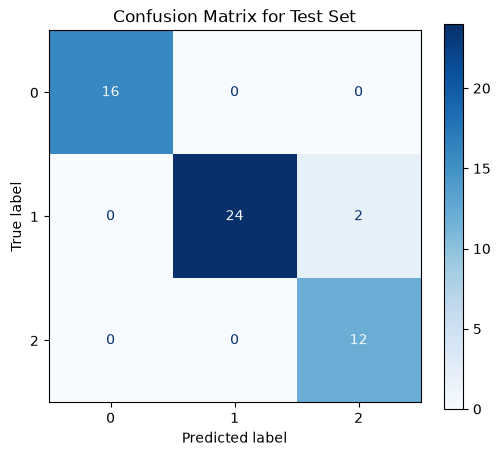

In [29]:
# Compute accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy}")

# Compute predictions and confusion matrix
conf_matrix_test = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
disp_test = ConfusionMatrixDisplay(conf_matrix_test, display_labels=svm_full.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp_test.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix for Test Set")
plt.show()

We now consider some problems based on the previous examples.

**Problem 1.** Above, we printed a histogram of the distribution of the `alcohol` feature. Pick a different feature and plot a histogram of it.

In this problem and all future problems, change the axis labels appropriately to match the new data being used. (For example, in this problem, the plot should no longer be label `alcohol', but instead labeled to match the new feature you choose.)

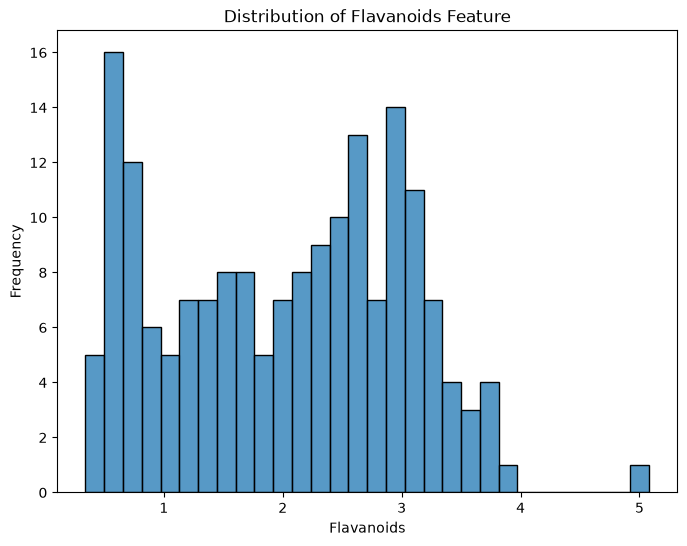

In [30]:
# Histogram of the 'flavanoids' feature
plt.figure(figsize=(8, 6))
sns.histplot(wine_df['flavanoids'], bins=30)
plt.title('Distribution of Flavanoids Feature')
plt.xlabel('Flavanoids')
plt.ylabel('Frequency')
plt.show()

**Problem 2.** Pick a pair of features different from the `alcohol` and `color_intensity` pair used above. Plot a scatterplot with these two class features and class labels by adapting the code from above.

Make sure to change the plot labels. Try to pick a pair where the classes display a decent amount of separation, since you will run a SVC on it in the next problem.

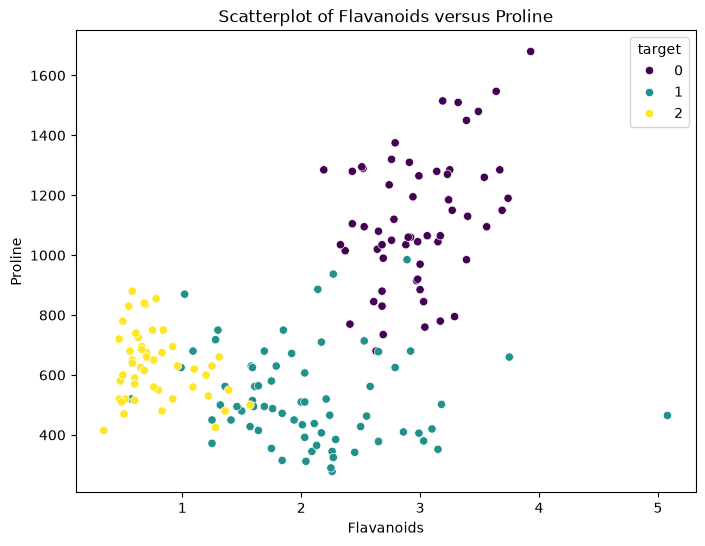

In [31]:
# Scatterplot of flavanoids versus proline, colored by class
plt.figure(figsize=(8, 6))
sns.scatterplot(x='flavanoids', y='proline', hue='target', data=wine_df, palette='viridis')
plt.title('Scatterplot of Flavanoids versus Proline')
plt.xlabel('Flavanoids')
plt.ylabel('Proline')
plt.show()


**Problem 3.** Copy the code from above that gave the red/blue plot with the margins and adapt it to use the features you selected in the previous problem. Change the plot labels as appropriate.

Give three plots, one for each of the choices C=0.1, C=1, and C=100. Keep the linear kernel. (You may need three different code blocks to get these plots to all display at once).

Notice how the margin varies with the value of C, as discussed in class.

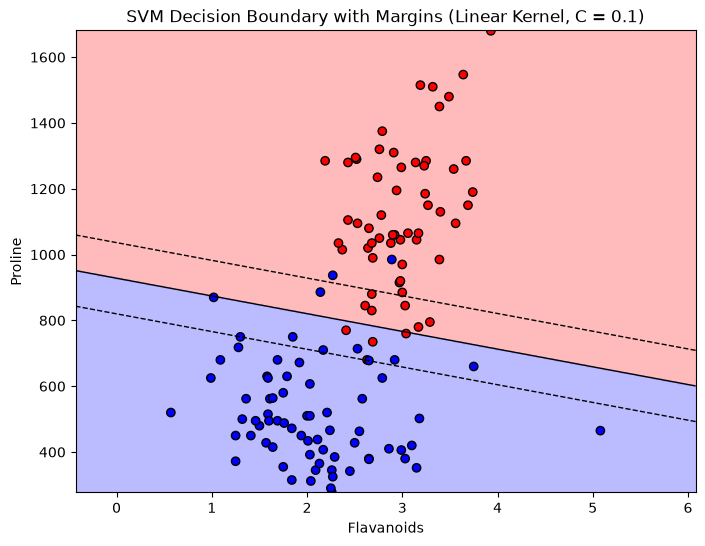

In [32]:
# first plot: C = 0.1
# Filter the dataset to include only classes 0 and 1
wine_filtered = wine_df[wine_df['target'] != 2]

# Select the features chosen in Problem 2
X = wine_filtered[['flavanoids', 'proline']].values
y = wine_filtered['target'].values

# Train the SVM with a linear kernel and C = 0.1
svm_binary = SVC(C=0.1, kernel='linear')
svm_binary.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict class labels for each point in the mesh (for solid color regions)
Z = svm_binary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Compute decision function values (for margin and decision boundary)
decision_values = svm_binary.decision_function(np.c_[xx.ravel(), yy.ravel()])
decision_values = decision_values.reshape(xx.shape)

# Plot the decision boundary with solid regions and margin lines
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.contour(xx, yy, decision_values, levels=[-1, 0, 1],
            linestyles=['--', '-', '--'], colors='k', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']), edgecolors='k')
plt.title('SVM Decision Boundary with Margins (Linear Kernel, C = 0.1)')
plt.xlabel('Flavanoids')
plt.ylabel('Proline')
plt.show()


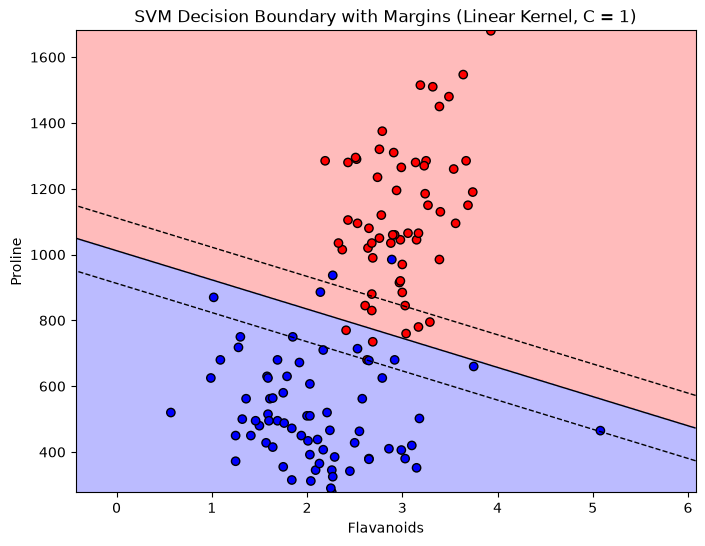

In [33]:
# second plot: C = 1
# Filter the dataset to include only classes 0 and 1
wine_filtered = wine_df[wine_df['target'] != 2]

# Select the features chosen in Problem 2
X = wine_filtered[['flavanoids', 'proline']].values
y = wine_filtered['target'].values

# Train the SVM with a linear kernel and C = 1
svm_binary = SVC(C=1, kernel='linear')
svm_binary.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict class labels for each point in the mesh (for solid color regions)
Z = svm_binary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Compute decision function values (for margin and decision boundary)
decision_values = svm_binary.decision_function(np.c_[xx.ravel(), yy.ravel()])
decision_values = decision_values.reshape(xx.shape)

# Plot the decision boundary with solid regions and margin lines
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.contour(xx, yy, decision_values, levels=[-1, 0, 1],
            linestyles=['--', '-', '--'], colors='k', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']), edgecolors='k')
plt.title('SVM Decision Boundary with Margins (Linear Kernel, C = 1)')
plt.xlabel('Flavanoids')
plt.ylabel('Proline')
plt.show()


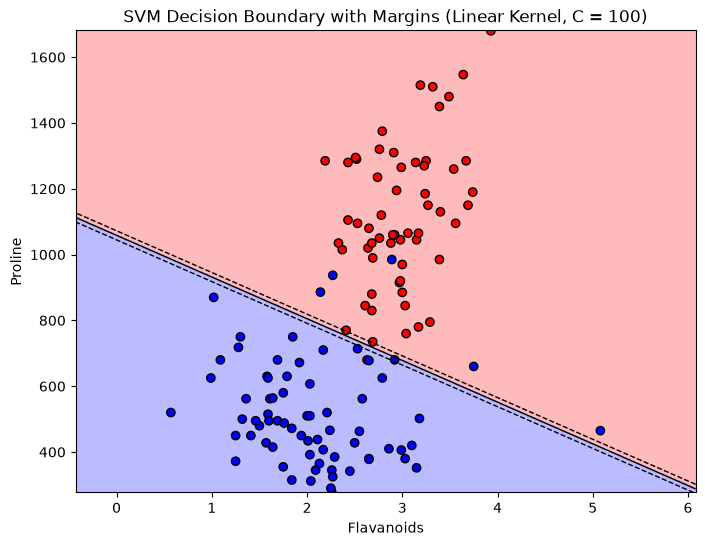

In [34]:
# third plot: C = 100
# Filter the dataset to include only classes 0 and 1
wine_filtered = wine_df[wine_df['target'] != 2]

# Select the features chosen in Problem 2
X = wine_filtered[['flavanoids', 'proline']].values
y = wine_filtered['target'].values

# Train the SVM with a linear kernel and C = 100
svm_binary = SVC(C=100, kernel='linear')
svm_binary.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict class labels for each point in the mesh (for solid color regions)
Z = svm_binary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Compute decision function values (for margin and decision boundary)
decision_values = svm_binary.decision_function(np.c_[xx.ravel(), yy.ravel()])
decision_values = decision_values.reshape(xx.shape)

# Plot the decision boundary with solid regions and margin lines
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.contour(xx, yy, decision_values, levels=[-1, 0, 1],
            linestyles=['--', '-', '--'], colors='k', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']), edgecolors='k')
plt.title('SVM Decision Boundary with Margins (Linear Kernel, C = 100)')
plt.xlabel('Flavanoids')
plt.ylabel('Proline')
plt.show()


**Problem 4.** Copy your C=1 code from the last problem (again using your selected features) and change the linear kernel to a polynomial kernel with degree 2. You may wish to consult [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) to see how to do this.

Run your code, which will produce a plot with the new (nonlinear) decision boundary and margin. Change the title to match the new kernel.

**Note.** More examples of SVM visualizations (with example code) can be found [in the scikit-learn documentation](https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py).

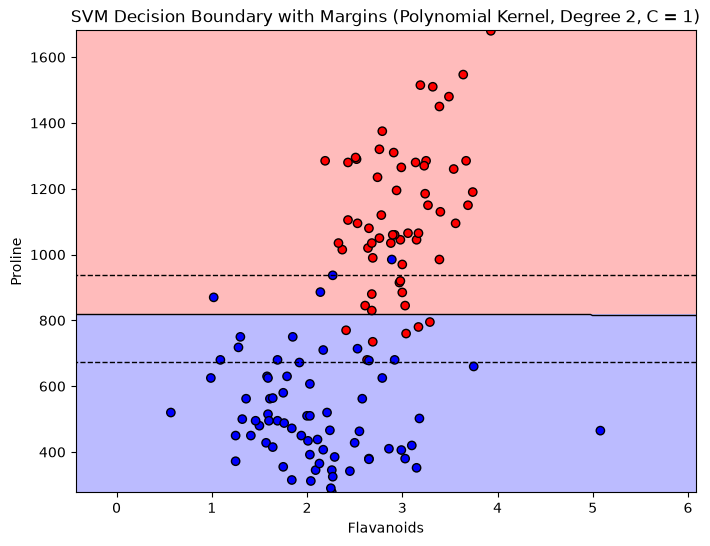

In [35]:
# plot
# Filter the dataset to include only classes 0 and 1
wine_filtered = wine_df[wine_df['target'] != 2]

# Select the features chosen in Problem 2
X = wine_filtered[['flavanoids', 'proline']].values
y = wine_filtered['target'].values

# Train the SVM with a linear kernel and C = 1
svm_binary = SVC(C=1, kernel='poly', degree=2)
svm_binary.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict class labels for each point in the mesh (for solid color regions)
Z = svm_binary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Compute decision function values (for margin and decision boundary)
decision_values = svm_binary.decision_function(np.c_[xx.ravel(), yy.ravel()])
decision_values = decision_values.reshape(xx.shape)

# Plot the decision boundary with solid regions and margin lines
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.contour(xx, yy, decision_values, levels=[-1, 0, 1],
            linestyles=['--', '-', '--'], colors='k', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']), edgecolors='k')
plt.title('SVM Decision Boundary with Margins (Polynomial Kernel, Degree 2, C = 1)')
plt.xlabel('Flavanoids')
plt.ylabel('Proline')
plt.show()


#Part 2: MNIST Digit Recognition

In the previous part, you saw an example of how a SVC was trained. In this part, you will train one yourself.

We begin by importing the MNIST dataset using a special data import function from `scikit-learn`, whose details are not important for us.

In [36]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

# Convert labels from strings to integers
y = y.astype(np.uint8)

Recall that in class, we said that this dataset consists of black and white images (represented as matrices of numbers) and labels (from 0 through 9). Let's check this using the `shape` command, which tells us the shape of an array.

In [37]:
print(y.shape)
print(y[0])
print(y[1])

(70000,)
5
0


We see that `y` is a collection of 70,000 integer labels. The first two are 5 and 0.

We now check `X`.

In [38]:
print(X.shape)
print(X[0])

(70000, 784)
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0  

We see that we have a collection of 70,000 vectors of length 784, representing the pixel values for the 28 by 28 images. It would be nice to visualize these, so let's do that.

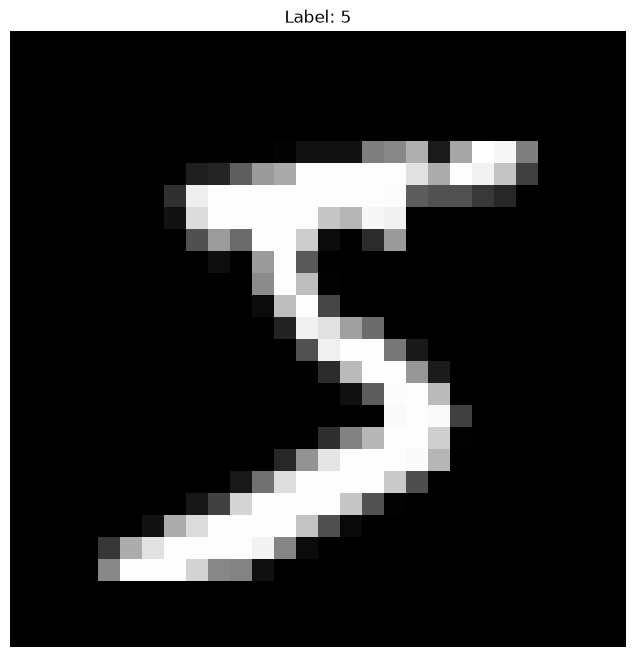

In [39]:
plt.figure(figsize=(8, 8))
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

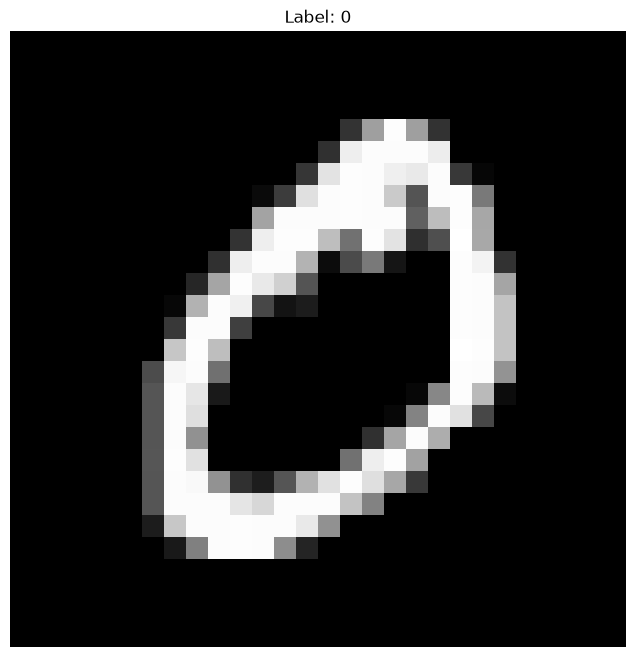

In [40]:
plt.figure(figsize=(8, 8))
plt.imshow(X[1].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[1]}")
plt.axis('off')
plt.show()

These match the labels we saw earlier, which is a good sign. You can try visualizing other datapoints, if you want.

To make this lab go faster, we are going to make the dataset smaller and just use the first 10,000 values. **Your solutions to the problems below should use only this smaller version.**

In [41]:
x_mnist = X[:10000]
y_mnist = y[:10000]

**Problem 1.** Train a support vector classifier on `x_mnist` and `y_mnist` with a linear kernel and C=1. Use a random train-test split with 20% of the data in the testing set (using the built-in function mentioned above, which chooses the split randomly). Print the label for the first element in your test set, and print the corresponding prediction from your classifier. (They may not match!)

Training may take anywhere from 10 to 30 seconds.

In [42]:
# Random train-test split with 20% of the data in the testing set
x_train, x_test, y_train, y_test = train_test_split(x_mnist, y_mnist, test_size=0.2)

# Train a support vector classifier with a linear kernel and C=1
svm_mnist = SVC(C=1, kernel='linear')
svm_mnist.fit(x_train, y_train)

# Predict on the test set
y_pred = svm_mnist.predict(x_test)

print("True label of first test element:", y_test[0])
print("Predicted label of first test element:", y_pred[0])


True label of first test element: 2
Predicted label of first test element: 2


**Problem 2.**

**Part A.** Calculate and print the accuracy of your classifier on the test set. Additionally, provide a confusion matrix.

**Part B.** You should notice that your classifier is fairly good at distinguishing digits that have distinct shapes, like 0 and 1. However, your confusion matrix should indicate that it has trouble on certain pairs of digits with similar shapes. What is one such pair that you observe? Write your answer below.

My classifier is having trouble with the following pair: 5 and 3

Test Accuracy: 0.9225
[[201   0   0   1   2   0   2   0   0   0]
 [  0 213   2   0   1   1   0   0   1   1]
 [  2   3 179   1   3   0   1   3   4   0]
 [  0   1   3 184   1   2   0   1   0   0]
 [  1   1   4   0 189   0   0   1   1   5]
 [  2   0   3  10   2 149   2   0   3   0]
 [  2   0   4   0   3   1 206   0   1   0]
 [  0   1   2   1   2   0   0 184   0   6]
 [  3   2   6   7   1   5   2   0 169   2]
 [  0   0   1   3  15   0   0  13   1 171]]


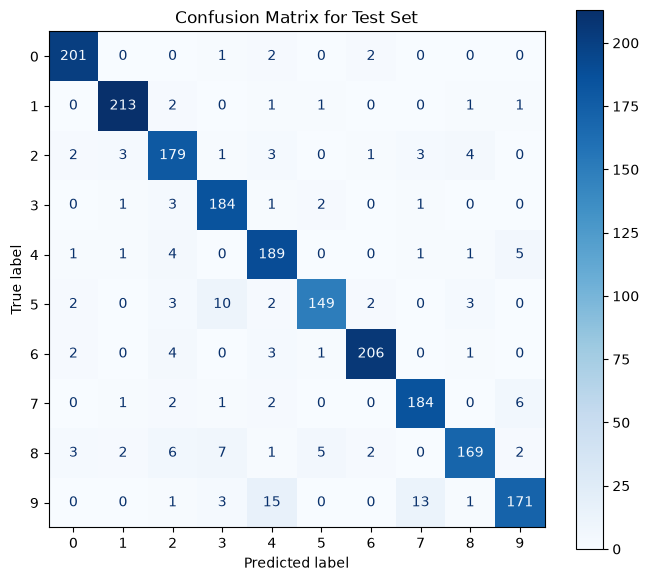

In [43]:
# Compute accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy}")

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=svm_mnist.classes_)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix for Test Set")
plt.show()


**Problem 3.** Train an SVM again on the same data, but with a different choice of C or kernel (or both). Provide the corresponding accuracy score and confusion matrix. A list of kernels can be found in the documentation linked in the previous part of this assignment. (If you use the `rbf` kernel, you can also try tweaking the `gamma` parameter.)

**To get full credit on this problem, you must achieve at least 94% accuracy on the test set.**

Test Accuracy: 0.976


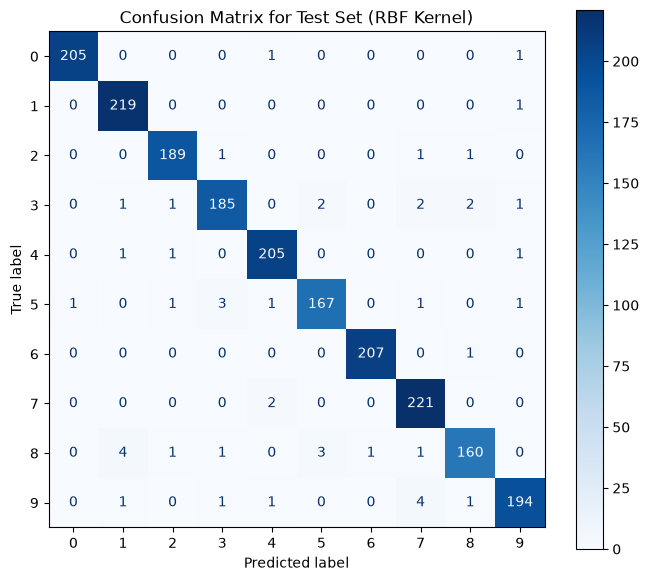

In [44]:
# Train an SVM with an RBF kernel and C=10
x_train, x_test, y_train, y_test = train_test_split(x_mnist, y_mnist, test_size=0.2)

svm_mnist_rbf = SVC(C=10, kernel='rbf')
svm_mnist_rbf.fit(x_train, y_train)

y_pred_rbf = svm_mnist_rbf.predict(x_test)

test_accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Test Accuracy: {test_accuracy_rbf}")

conf_matrix_rbf = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(conf_matrix_rbf, display_labels=svm_mnist_rbf.classes_)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix for Test Set (RBF Kernel)")
plt.show()


**Problem 4.** Look at the scikit-learn documentation for [k-nearest neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). By replacing `SVC(C = 1, kernel='linear')` with `KNeighborsClassifier(n_neighbors=5)` in your previous code, create a classifier using the 5 nearest neighbors in the training set, then fit it on the data from the last few problems. Print the accuracy and display a confusion matrix for the k-nearest neighbors classifier.

Test Accuracy: 0.9425


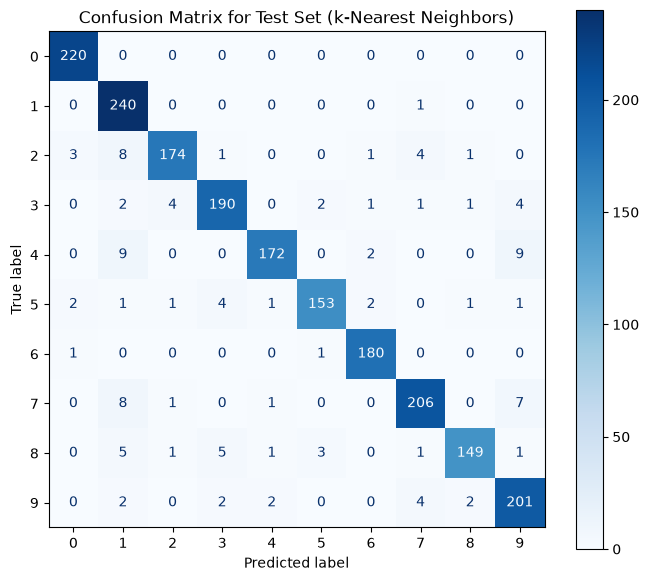

In [45]:
# k-nearest neighbors classifier with n_neighbors=5
x_train, x_test, y_train, y_test = train_test_split(x_mnist, y_mnist, test_size=0.2)

knn_mnist = KNeighborsClassifier(n_neighbors=5)
knn_mnist.fit(x_train, y_train)

y_pred_knn = knn_mnist.predict(x_test)

test_accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Test Accuracy: {test_accuracy_knn}")

conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(conf_matrix_knn, display_labels=knn_mnist.classes_)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix for Test Set (k-Nearest Neighbors)")
plt.show()


#Postscript

You may wish to experiment with hyperparameter tuning to see how good you can make your classifier.

Eventually, you are going to realize that there is a ceiling to how well you can do with this amount of data, and want to train on the full dataset (not just the first 10000 entries). If you're interested, you can try this and see how long it takes. (With a linear kernel, it took me about 30 minutes.) Accuracy will be a little better, but that's a long time to train. This is a common problem for many machine learning algorithms, not just SVC. This problem motivates the need for good data compression (representing our images with smaller vectors without much loss of accuracy), so that we can use the full data with less training time. A basic method for compression using linear algebra will be the subject of the next lab.

My experiments show that k-nearest neighbors is much faster, but not quite as accurate, as SVC after tuning hyperparameters. The accuracy discrepancy is small here but can be larger on more difficult datasets. We would like to preserve the accuracy edge of SVC while reducing the speed deficit.

Note that SVC is not universally more accurate than k-NN, so you should really try both in any practical application.